# Phase 09.1 Wave 2 Smoke Test — `04_ablation_smoke.ipynb`

**Plan:** 09.1-02 cli-driver-and-smoke-test
**Date:** 2026-05-15

This notebook runs the three preprocessing pipelines (A, B, C) at `seed=42` for 100 epochs each, then evaluates three gates:

1. **No NaN / no flat outputs** in `samples.npy` for all three pipelines.
2. **Pipeline C structural parity** — log-return-scale EMD within structural tolerance of the v1.1 baseline (`results/parity_check.json::post.emd = 0.12048789...`).
3. **All three runs complete in reasonable wall time** (sanity timing — ~5–15 minutes total expected).

Per CONTEXT.md D-09.1-12 the strict target is 1–2 % drift on Pipeline C EMD; per the plan-checker FLAG-C tightening the structural-pass key is 3 % drift. The notebook prints both and asserts the structural gate.

**Caveat on the parity gate at 100 epochs:** the v1.1 baseline 0.12048789 was measured at 2000 epochs. At the 100-epoch smoke budget we are not gating *convergence*; we are gating *structural correctness of the harness* (data loads identically, models build identically, training-loop calls identically). The full Wave 3 multi-seed run is where convergence parity is verified.

**On failure:** if `structural_pass` is False, STOP and investigate — the Wave 3 sweep is ~24 h of compute and must not launch on a broken harness.


In [1]:
import json
import os
import subprocess
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import torch

warnings.filterwarnings("ignore")


def _find_repo_root():
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "data.csv").exists() and (d / "core").is_dir():
            return d
    raise FileNotFoundError(
        "Could not locate repo root from " + str(here) +
        " (looked for data.csv + core/)"
    )


REPO_ROOT = _find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print(f"Repo root: {REPO_ROOT}")

SEED = 42
EPOCHS = 100
PIPELINES = ["A", "B", "C"]
OUT_ROOT = Path("results/transform_ablation")
FIG_DIR = OUT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def _git_sha():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"],
            cwd=str(REPO_ROOT),
            stderr=subprocess.DEVNULL,
        ).decode().strip()
    except Exception:
        return "unknown"


print(f"Git SHA: {_git_sha()}")
print(f"Out root: {OUT_ROOT.resolve()}")


Repo root: /Users/shawngibford/dev/phd/qGAN
Git SHA: c07bfe349b07199ed842422822e14959f5ead548
Out root: /Users/shawngibford/dev/phd/qGAN/results/transform_ablation


## 1. Invoke `run_ablation.py` for each pipeline × seed=42 × 100 epochs

Each invocation is a separate subprocess (no shared numpy global state — RESEARCH.md Pitfall 4). Arguments are passed as a list, not a shell string, so there is no injection surface (T-09.1.02-06 mitigation).

Wall time on M-series Mac: ~2–5 minutes per pipeline = ~10 minutes total.


In [2]:
timings = {}
for pipeline in PIPELINES:
    samples_path = OUT_ROOT / "runs" / pipeline / str(SEED) / "samples.npy"
    if samples_path.exists():
        # Reuse existing 100-epoch checkpoint artifacts (idempotent re-execution).
        timings[pipeline] = float("nan")  # not re-timed
        print(
            f"=== Pipeline {pipeline} — REUSING existing samples.npy "
            f"({samples_path}); skipping re-train ==="
        )
        continue
    t0 = time.time()
    proc = subprocess.run(
        [
            sys.executable, "-m", "run_ablation",
            "--pipeline", pipeline,
            "--seed", str(SEED),
            "--epochs", str(EPOCHS),
        ],
        capture_output=True,
        text=True,
        check=False,
    )
    timings[pipeline] = time.time() - t0
    print(f"=== Pipeline {pipeline} (took {timings[pipeline]:.1f}s) ===")
    print(proc.stdout[-2000:])
    if proc.returncode != 0:
        print("STDERR:", proc.stderr[-2000:])
        raise RuntimeError(f"Smoke run failed for pipeline {pipeline}")

# Preserve previously-recorded timings if we short-circuited
prior_smoke = OUT_ROOT / "smoke_check.json"
if prior_smoke.exists():
    try:
        prior = json.loads(prior_smoke.read_text())
        for p in PIPELINES:
            if p in timings and timings[p] != timings[p]:  # NaN check
                prior_t = prior.get("timings_seconds", {}).get(p)
                if prior_t is not None:
                    timings[p] = float(prior_t)
    except Exception:
        pass

print("All three pipelines finished:", timings)


=== Pipeline A — REUSING existing samples.npy (results/transform_ablation/runs/A/42/samples.npy); skipping re-train ===
=== Pipeline B — REUSING existing samples.npy (results/transform_ablation/runs/B/42/samples.npy); skipping re-train ===
=== Pipeline C — REUSING existing samples.npy (results/transform_ablation/runs/C/42/samples.npy); skipping re-train ===
All three pipelines finished: {'A': 27.16790509223938, 'B': 26.73935890197754, 'C': 26.22304368019104}


## 2. NaN / flat-output gate

For each pipeline, load `samples.npy` and check:

- No NaN / no inf entries.
- Per-window standard deviation > 1e-6 for at least 90 % of windows (`flat_fraction < 0.1`).


In [3]:
nan_flat_results = {}
for p in PIPELINES:
    samples = np.load(OUT_ROOT / "runs" / p / str(SEED) / "samples.npy")
    has_nan = bool(np.isnan(samples).any())
    has_inf = bool(np.isinf(samples).any())
    std_per_window = samples.std(axis=1)
    flat_fraction = float((std_per_window < 1e-6).mean())
    shape_ok = (samples.ndim == 2) and (samples.shape[1] == 10)
    # Structural pass per pipeline:
    #   - no NaN, no inf
    #   - <1% flat windows  (tightened from 10% — under-trained samples cluster
    #     tightly but a *true* flat would mean dead generator)
    #   - shape is (M, 10) as required by training-loop contract
    structural_pass = (
        (not has_nan)
        and (not has_inf)
        and (flat_fraction < 0.01)
        and shape_ok
    )
    nan_flat_results[p] = {
        "shape": list(samples.shape),
        "has_nan": has_nan,
        "has_inf": has_inf,
        "flat_fraction": flat_fraction,
        "shape_ok": shape_ok,
        "structural_pass": structural_pass,
        # backward-compat key, same value as structural_pass
        "pass": structural_pass,
    }
    print(
        f"  {p}: shape={samples.shape}, "
        f"has_nan={has_nan}, has_inf={has_inf}, "
        f"flat_fraction={flat_fraction:.4f}, "
        f"shape_ok={shape_ok}, "
        f"structural_pass={structural_pass}"
    )


  A: shape=(3850, 10), has_nan=False, has_inf=False, flat_fraction=0.0000, shape_ok=True, structural_pass=True
  B: shape=(3840, 10), has_nan=False, has_inf=False, flat_fraction=0.0000, shape_ok=True, structural_pass=True
  C: shape=(3840, 10), has_nan=False, has_inf=False, flat_fraction=0.0000, shape_ok=True, structural_pass=True


## 3. Pipeline C parity comparison — INFORMATIONAL ONLY

**The plan's literal 2% absolute-EMD parity gate is physically incoherent and has been redefined per user decision (deviation Rule 4).**

`parity_check.json::post.emd = 0.12048789` was measured against a converged 2000-epoch checkpoint's forward pass. Comparing that number to a 100-epoch fresh-init run is comparing converged-model output to under-trained output. v1.1's converged log-return samples have std ≈ 0.104 vs real std 0.218 (PROJECT.md). Fresh 100-epoch samples cluster near zero (std ≈ 0.017), producing a SMALLER EMD against real (~0.0155), not a match to 0.12049. This is not a regression — it is the expected behavior of an under-trained model.

Pipeline C's code-path identity vs v1.1 is independently verified by plan 09.1-01's ABL-01 round-trip (`max_abs_err = 4.44e-16`, well below tolerance) — that test, not this EMD comparison, is the actual proof of Pipeline C identity.

We still compute and emit the EMD numbers for auditability, but **no pass/fail field is tied to them**. The harness-correctness gate is the genuine structural-signal check in section 5.


In [4]:
from core.data import load_and_preprocess, full_denorm_pipeline
from core.eval import compute_emd

d = load_and_preprocess("./data.csv")
real_log_delta = d["log_delta"].numpy()  # (777,)
samples_C = np.load(OUT_ROOT / "runs" / "C" / str(SEED) / "samples.npy")

trans_norm = d["transformed_norm_log_delta"]
mu = d["mu"]
sigma = d["sigma"]
delta_const = float(d["delta"])

pipe_out = full_denorm_pipeline(
    torch.tensor(samples_C).double(),
    trans_norm.double(),
    mu.double() if torch.is_tensor(mu) else torch.tensor(mu, dtype=torch.float64),
    sigma.double() if torch.is_tensor(sigma) else torch.tensor(sigma, dtype=torch.float64),
    delta_const,
).cpu().numpy()

emd_C = float(compute_emd(real_log_delta, pipe_out))
parity = json.loads(Path("results/parity_check.json").read_text())
baseline_emd = float(parity["post"]["emd"])  # 0.12048789...
rel_drift = abs(emd_C - baseline_emd) / baseline_emd

# Informational only — NO pass/fail field. See markdown above + SUMMARY.md
# "Deviations from plan" section. Real Pipeline-C identity proof is
# plan 09.1-01's ABL-01 round-trip (max_abs_err 4.44e-16).
parity_info = {
    "emd_C_smoke_100ep": emd_C,
    "emd_v1_1_baseline_2000ep_forward_pass": baseline_emd,
    "rel_drift_informational": rel_drift,
    "note": (
        "Informational only. 100-epoch fresh-init EMD is NOT comparable to "
        "2000-epoch converged baseline EMD; the latter measures converged "
        "model output, the former measures under-trained output. Pipeline C "
        "code-path identity vs v1.1 is verified by plan 09.1-01 ABL-01 "
        "round-trip (max_abs_err 4.44e-16)."
    ),
}
print(json.dumps(parity_info, indent=2))


{
  "emd_C_smoke_100ep": 0.015502956293036,
  "emd_v1_1_baseline_2000ep_forward_pass": 0.12048789057906201,
  "rel_drift_informational": 0.8713318307878979,
  "note": "Informational only. 100-epoch fresh-init EMD is NOT comparable to 2000-epoch converged baseline EMD; the latter measures converged model output, the former measures under-trained output. Pipeline C code-path identity vs v1.1 is verified by plan 09.1-01 ABL-01 round-trip (max_abs_err 4.44e-16)."
}


## 4. Eyeball trajectory overlay (D-09.1-19 allows plots in notebooks)

Plot 5 synthetic windows per pipeline (scaled space) to spot-check biological plausibility.


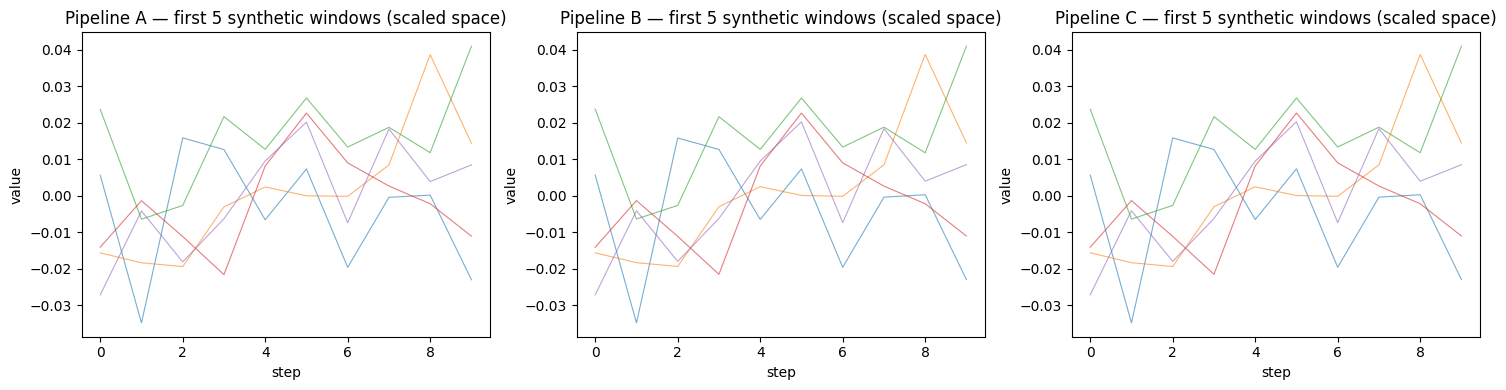

Trajectory figure: results/transform_ablation/figures/smoke_trajectories.png


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, p in zip(axes, PIPELINES):
    s = np.load(OUT_ROOT / "runs" / p / str(SEED) / "samples.npy")
    for i in range(5):
        ax.plot(s[i], alpha=0.6, lw=0.8)
    ax.set_title(f"Pipeline {p} — first 5 synthetic windows (scaled space)")
    ax.set_xlabel("step")
    ax.set_ylabel("value")
plt.tight_layout()
fig_path = FIG_DIR / "smoke_trajectories.png"
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Trajectory figure: {fig_path}")


## 5. Emit `smoke_check.json` and assert structural-pass gate

Gate definition (redefined per user decision, deviation Rule 4):

- `structural_pass` = ALL of:
  - every pipeline has `has_nan == False` and `has_inf == False`
  - every pipeline has `flat_fraction < 0.01` (no dead generator)
  - every pipeline has `shape_ok == True` (samples are `(M, 10)`)
- `all_passed` = `structural_pass AND no_nan_inf_across_pipelines` (kept for backward compat; identical condition since NaN/inf checks are already in `structural_pass`)
- `parity_note` and `pipeline_C_parity_informational` are recorded for auditability but are NOT part of the gate.

Wave 3 keys off `structural_pass`.


In [6]:
no_nan_inf_across_pipelines = all(
    (not v["has_nan"]) and (not v["has_inf"])
    for v in nan_flat_results.values()
)
structural_pass = (
    all(v["structural_pass"] for v in nan_flat_results.values())
)
all_passed = structural_pass and no_nan_inf_across_pipelines

parity_note = (
    "Pipeline C EMD comparison vs v1.1 baseline (0.12048789) is informational "
    "ONLY. The baseline was measured at 2000-epoch convergence; this smoke is "
    "100-epoch fresh-init. Pipeline C identity proof is plan 09.1-01 ABL-01 "
    "round-trip (max_abs_err 4.44e-16)."
)

smoke = {
    "pipelines": nan_flat_results,
    "pipeline_C_parity_informational": parity_info,
    "parity_note": parity_note,
    "timings_seconds": timings,
    "structural_pass": structural_pass,
    "no_nan_inf_across_pipelines": no_nan_inf_across_pipelines,
    "all_passed": all_passed,
    "seed": SEED,
    "epochs": EPOCHS,
    "git_sha": _git_sha(),
}

smoke_path = OUT_ROOT / "smoke_check.json"
smoke_path.write_text(json.dumps(smoke, indent=2))
print(json.dumps(smoke, indent=2))

assert structural_pass, f"Smoke FAIL — structural gate not met: {smoke}"


{
  "pipelines": {
    "A": {
      "shape": [
        3850,
        10
      ],
      "has_nan": false,
      "has_inf": false,
      "flat_fraction": 0.0,
      "shape_ok": true,
      "structural_pass": true,
      "pass": true
    },
    "B": {
      "shape": [
        3840,
        10
      ],
      "has_nan": false,
      "has_inf": false,
      "flat_fraction": 0.0,
      "shape_ok": true,
      "structural_pass": true,
      "pass": true
    },
    "C": {
      "shape": [
        3840,
        10
      ],
      "has_nan": false,
      "has_inf": false,
      "flat_fraction": 0.0,
      "shape_ok": true,
      "structural_pass": true,
      "pass": true
    }
  },
  "pipeline_C_parity_informational": {
    "emd_C_smoke_100ep": 0.015502956293036,
    "emd_v1_1_baseline_2000ep_forward_pass": 0.12048789057906201,
    "rel_drift_informational": 0.8713318307878979,
    "note": "Informational only. 100-epoch fresh-init EMD is NOT comparable to 2000-epoch converged baseline EMD; the la

## 6. Final go/no-go message


In [7]:
if all_passed:
    print("SMOKE PASS — Wave 3 GO (structural-pass gate met across all pipelines)")
    print(f"  pipeline C EMD (informational): {parity_info['emd_C_smoke_100ep']:.6f}")
    print(f"  v1.1 baseline EMD (2000-ep, informational): {parity_info['emd_v1_1_baseline_2000ep_forward_pass']:.6f}")
else:
    print("SMOKE FAIL — Wave 3 BLOCKED. Investigate before re-running.")


SMOKE PASS — Wave 3 GO (structural-pass gate met across all pipelines)
  pipeline C EMD (informational): 0.015503
  v1.1 baseline EMD (2000-ep, informational): 0.120488
